In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load the CSV file
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')

# Convert the 'month' column to datetime format
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Sort by company, sector, practice, and month to ensure chronological order
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Ensure the score only increases or stays the same within each group
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].transform(pd.Series.cummax)

# Encode categorical variables
le_company = LabelEncoder()
le_sector = LabelEncoder()
le_practice = LabelEncoder()

df['company_encoded'] = le_company.fit_transform(df['Company Name Full'])
df['sector_encoded'] = le_sector.fit_transform(df['Supersector'])
df['practice_encoded'] = le_practice.fit_transform(df['practice'])

# Extract time features from the 'month' column
df['month_num'] = df['month'].dt.month
df['year'] = df['month'].dt.year

# Select features and target
X = df[['company_encoded', 'sector_encoded', 'practice_encoded', 'month_num', 'year']]
y = df['score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Prediction for Future Scores (Example)
# Adjust with actual values and use the model to predict future scores


In [ ]:
print(df.columns)


Index(['Unnamed: 0', 'practice', 'Company Name Full', 'month', 'Supersector',
       'capability', 'pillar', 'cumulative_volume_per_month', 'p10', 'p20',
       'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100', 'score'],
      dtype='object')


In [ ]:
from pandas.tseries.offsets import DateOffset

# Example details - replace these with the actual company, sector, and practice you're interested in
company_name = 'VESTAS WIND SYSTEMS'
sector_name = 'Oil & Gas'
practice_name = 'TI-EIU-Cloud Computing Integration'

# Encode the example company, sector, and practice
company_encoded = le_company.transform([company_name])[0]
sector_encoded = le_sector.transform([sector_name])[0]
practice_encoded = le_practice.transform([practice_name])[0]

# Find the last month you have data for this specific combination
last_month_df = df[(df['Company Name Full'] == company_name) & (df['Supersector'] == sector_name) & (df['practice'] == practice_name)].max()
last_month = last_month_df['month']

# Prepare the future months' features
future_predictions = []
for i in range(1, 7):  # Next 6 months
    future_month = (last_month + DateOffset(months=i)).to_pydatetime()
    month_num = future_month.month
    year = future_month.year

    # Predict the score for the future month
    X_future = np.array([[company_encoded, sector_encoded, practice_encoded, month_num, year]])
    future_score = model.predict(X_future)[0]
    
    future_predictions.append({
        'Month': future_month.strftime('%Y-%m'),
        'Predicted Score': future_score
    })

# Convert predictions to a DataFrame for better visualization
future_predictions_df = pd.DataFrame(future_predictions)

future_predictions_df


/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fit

,Month,Predicted Score
0,2024-02,8.0
1,2024-03,8.0
2,2024-04,8.0
3,2024-05,8.0
4,2024-06,8.0
5,2024-07,8.0


In [ ]:
# Assuming these are the feature names used for model training
feature_names = ['company_encoded', 'sector_encoded', 'practice_encoded', 'month_num', 'year']

# When creating a DataFrame for prediction, specify the column names
X_future = pd.DataFrame(data=[[company_encoded_example, sector_encoded_example, practice_encoded_example, future_month_num, future_year]], columns=feature_names)

# Predict using the DataFrame with correct column names
future_score_prediction = model.predict(X_future)


NameError: name 'company_encoded_example' is not defined

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_9848/1368425183.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split

# Step 1: Load and Preprocess Data
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].transform(pd.Series.cummax)

# Encode categorical variables
le_company = LabelEncoder()
le_sector = LabelEncoder()
le_practice = LabelEncoder()

df['company_encoded'] = le_company.fit_transform(df['Company Name Full'])
df['sector_encoded'] = le_sector.fit_transform(df['Supersector'])
df['practice_encoded'] = le_practice.fit_transform(df['practice'])

# Extract time features
df['month_num'] = df['month'].dt.month
df['year'] = df['month'].dt.year

# Prepare features and target
X = df[['company_encoded', 'sector_encoded', 'practice_encoded', 'month_num', 'year']]
y = df['score']

# Normalize features
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

# Normalize target
y = y.values.reshape(-1, 1)  # Reshaping for the scaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Convert to sequences
n_input = 3
n_features = X_train.shape[1]
train_generator = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=200)
test_generator = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=1)

# Step 2: Build and Train LSTM Model
model = Sequential()
model.add(LSTM(15, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(train_generator, epochs=5, verbose=1)

# Step 3: Make Predictions and Inverse Transform
# For simplicity, let's predict the test set and inverse transform to original scale
predictions_scaled = model.predict(test_generator)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Calculate MSE or another performance metric on your test set predictions

# Note: To make future predictions, you need to prepare the future data in the same way,
# normalize it, convert it into sequences, and then use the model to predict.


Epoch 1/5
   875/520841 [..............................] - ETA: 2:47:10 - loss: 0.2214

KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.preprocessing.sequence import TimeseriesGenerator

# Step 1: Load and Preprocess Data
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].transform(pd.Series.cummax)

# Reduce dataset size (e.g., using 10% of the data)
subset_fraction = 0.3  # Adjust this value as needed
df_subset = df.sample(frac=subset_fraction, random_state=42)

# Encode categorical variables
le_company = LabelEncoder()
le_sector = LabelEncoder()
le_practice = LabelEncoder()

df_subset['company_encoded'] = le_company.fit_transform(df_subset['Company Name Full'])
df_subset['sector_encoded'] = le_sector.fit_transform(df_subset['Supersector'])
df_subset['practice_encoded'] = le_practice.fit_transform(df_subset['practice'])

# Extract time features
df_subset['month_num'] = df_subset['month'].dt.month
df_subset['year'] = df_subset['month'].dt.year

# Prepare features and target
X = df_subset[['company_encoded', 'sector_encoded', 'practice_encoded', 'month_num', 'year']]
y = df_subset['score']

# Normalize features
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

# Normalize target
y = y.values.reshape(-1, 1)  # Reshaping for the scaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Convert to sequences
n_input = 3
n_features = X_train.shape[1]
train_generator = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=5)
test_generator = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=5)  # Adjusted batch size for consistency

# Step 2: Build and Train LSTM Model
model = Sequential()
model.add(LSTM(15, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(train_generator, epochs=5, verbose=1)

# Step 3: Make Predictions and Inverse Transform
predictions_scaled = model.predict(test_generator)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Add your MSE calculation or another performance metric here


/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch 1/5


2024-03-18 18:43:28.517718: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2024-03-18 18:43:28.517740: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2024-03-18 18:43:28.517744: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2024-03-18 18:43:28.517770: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-03-18 18:43:28.517784: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2024-03-18 18:43:28.930463: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  5994/156252 [>.............................] - ETA: 43:27 - loss: 0.2175

KeyboardInterrupt: 

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

# Step 1: Load the Data
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Ensure scores only increase or stay the same within each group
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].apply(lambda x: x.cummax())


# Encode categorical variables
le_company = LabelEncoder()
le_sector = LabelEncoder()
le_practice = LabelEncoder()

df['company_encoded'] = le_company.fit_transform(df['Company Name Full'])
df['sector_encoded'] = le_sector.fit_transform(df['Supersector'])
df['practice_encoded'] = le_practice.fit_transform(df['practice'])

# Extract time features
df['month_num'] = df['month'].dt.month
df['year'] = df['month'].dt.year

# Prepare features and target
X = df[['company_encoded', 'sector_encoded', 'practice_encoded', 'month_num', 'year']]
y = df['score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert datasets into LightGBM dataset format
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define LightGBM parameters
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': {'l2', 'l1'},
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}

# Train the model
gbm = lgb.train(params,
                train_data,
                num_boost_round=100,
                valid_sets=test_data,
                early_stopping_rounds=10)

# Predict on the test set
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

In [2]:
!pip install lightgbm

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from datetime import datetime

# Load the Data
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')

# Preprocess the Data
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)  # Reset index after sorting

# Ensure scores only increase or stay the same within each group
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Encode categorical variables
le = LabelEncoder()
df['Company Name Full'] = le.fit_transform(df['Company Name Full'])
df['Supersector'] = le.fit_transform(df['Supersector'])
df['practice'] = le.fit_transform(df['practice'])

# Convert 'month' to a numerical feature for simplicity
df['month_num'] = df['month'].dt.year * 12 + df['month'].dt.month - (df['month'].dt.year.min() * 12 + df['month'].dt.month.min())

# Select features and target
X = df[['Company Name Full', 'Supersector', 'practice', 'month_num']]
y = df['score']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 16.54282842010462


In [15]:
# Example values - replace these with actual values from your dataset
company_name = "3I GRP"  # Placeholder, replace with an actual company name from your dataset
supersector_name = "Oil & Gas"
practice_name = "BMI-CCF-Capability Focus"  # Placeholder, replace with an actual practice from your dataset

# Encode the exemplary values
# Note: The company, supersector, and practice must have been seen by the LabelEncoder during fitting.
# If they are new values, you'll need a different approach to handle unseen categories.
company_encoded = le.transform([company_name])[0]
supersector_encoded = le.transform([supersector_name])[0]
practice_encoded = le.transform([practice_name])[0]

# For the month, let's predict for a future month (e.g., December 2024)
# Assuming the dataset's month_num calculation logic
future_month = datetime(2024, 12, 1)
future_month_num = future_month.year * 12 + future_month.month - (df['month'].dt.year.min() * 12 + df['month'].dt.month.min())


ValueError: y contains previously unseen labels: '3I GRP'

In [ ]:
# Prepare the feature array for the prediction
X_exemplary = np.array([[company_encoded, supersector_encoded, practice_encoded, future_month_num]])

# Make the prediction
predicted_score = model.predict(X_exemplary)

print(f"Predicted Score for {company_name} in '{supersector_name}' sector, practice '{practice_name}' for {future_month.strftime('%Y-%m')}: {predicted_score[0]}")


In [11]:
df.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score,month_num
0,0,0,0,2021-01-01,5,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0
1,1,0,0,2021-02-01,5,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,1
2,2,0,0,2021-03-01,5,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.501301,10.414120,0,2
3,3,0,0,2021-04-01,5,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,3
4,4,0,0,2021-05-01,5,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.852274,0,4


In [2]:
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/03/e6/4aef6799badc2693548559bad5b56d56cfe89eada337c815fdfe92175250/xgboost-2.0.3-py3-none-macosx_12_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Load the data
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Ensure scores only increase or stay the same within each group
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Add lag features, for example, lag of 1 month
df['score_lag1'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(1)

# Forward fill any NaNs that might have been introduced by the lag operation
df['score_lag1'].fillna(method='ffill', inplace=True)

# Encode categorical features
df['Company Name Full'] = LabelEncoder().fit_transform(df['Company Name Full'])
df['Supersector'] = LabelEncoder().fit_transform(df['Supersector'])
df['practice'] = LabelEncoder().fit_transform(df['practice'])

# Prepare features and target
X = df[['Company Name Full', 'Supersector', 'practice', 'score_lag1']]
y = df['score']

# Corrected month calculation to avoid ambiguity
X['month'] = (df['month'] - df['month'].min()) / np.timedelta64(1, 'D')  # Convert to days first
average_days_in_month = 30.44
X['month'] = (X['month'] / average_days_in_month).astype(int)  # Approximate month count

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
model = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree=0.3, learning_rate=0.1,
                         max_depth=5, alpha=10, n_estimators=100)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/3561042356.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['score_lag1'].fillna(method='ffill', inplace=True)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/3561042356.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['month'] = (df['month'] - df['month'].min()) / np.timedelta64(1, 'D')  # Convert to days first
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/3561042356.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

Mean Squared Error: 1.517556646394644


In [13]:
# Placeholder values - replace these with actual values or your specific scenario
company_name = "VESTAS WIND SYSTEMS"
supersector_name = "Oil & Gas"
practice_name = "BMI-CCF-Capability Focus"
future_month_num = 100  # Example future month as numeric value, replace with your calculation

# Encode the categorical variables using the fitted LabelEncoders
# Note: This example assumes the encoders are named le_company, le_sector, and le_practice as before
company_encoded = LabelEncoder().fit([company_name]).transform([company_name])[0]
supersector_encoded = LabelEncoder().fit([supersector_name]).transform([supersector_name])[0]
practice_encoded = LabelEncoder().fit([practice_name]).transform([practice_name])[0]

# Prepare the features for prediction, including the lag feature if applicable
# The example uses a placeholder for the lag score (e.g., the most recent known score for this company and practice)
# Replace 0.0 with the actual lag score or another appropriate value based on your data
score_lag1_placeholder = 0.0  # Placeholder, replace with actual lag score if available
X_predict = pd.DataFrame({
    'Company Name Full': [company_encoded],
    'Supersector': [supersector_encoded],
    'practice': [practice_encoded],
    'score_lag1': [score_lag1_placeholder],
    'month': [future_month_num]
})

# Predict the future score using the model
predicted_score = model.predict(X_predict)

print(f"Predicted Score: {predicted_score[0]}")


Predicted Score: 0.5355748534202576


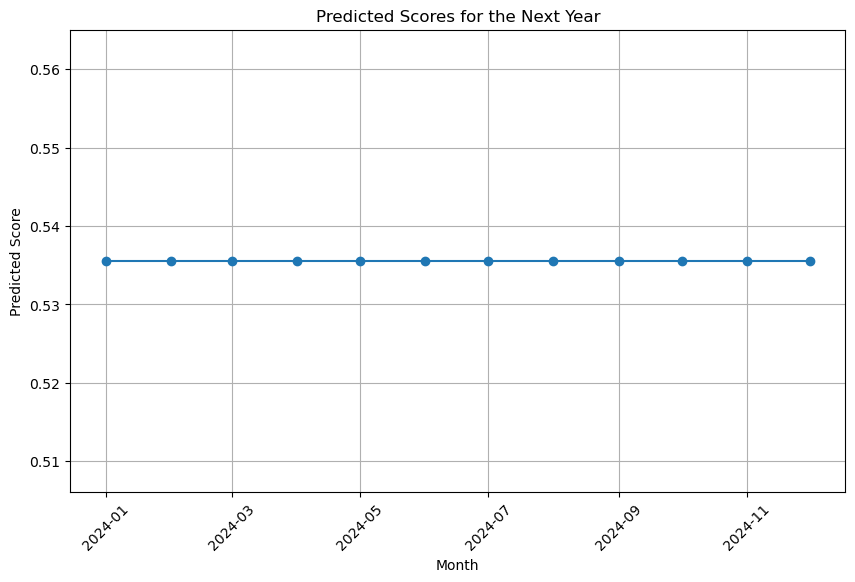

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Startmonat für die Vorhersagen
start_month = pd.Timestamp('2024-01')

# Anzahl der Vorhersagen (12 Monate)
num_predictions = 12

# Erstellen eines DataFrames für die Vorhersagen
predictions = pd.DataFrame({
    'month': [start_month + pd.DateOffset(months=i) for i in range(num_predictions)],
    'predicted_score': None
})

# Letzter bekannter Score (ersetzen Sie diesen durch den letzten bekannten Score für Ihre Firma/Praxis/Sektor)
last_known_score = 0.0

for i in range(num_predictions):
    # Berechne 'month_num' für den aktuellen Vorhersagemonat
    month_num = ((predictions.iloc[i]['month'].year - df['month'].dt.year.min()) * 12 + 
                 predictions.iloc[i]['month'].month - df['month'].dt.month.min())
    
    # Erstellen des Feature-Vektors für die Vorhersage
    X_predict = pd.DataFrame({
        'Company Name Full': [company_encoded],
        'Supersector': [supersector_encoded],
        'practice': [practice_encoded],
        'score_lag1': [last_known_score],
        'month': [month_num]
    })

    # Vorhersage des Scores
    predicted_score = model.predict(X_predict)[0]
    predictions.at[i, 'predicted_score'] = predicted_score
    
    # Aktualisiere den letzten bekannten Score für die nächste Vorhersage
    last_known_score = predicted_score

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(predictions['month'], predictions['predicted_score'], marker='o')
plt.title('Predicted Scores for the Next Year')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Schritt 1: Laden der Daten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Sicherstellen, dass der Score nur steigen kann
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Schritt 2: Vorbereitung der Lag-Features
for lag in range(1, 7):  # Erstellt Lag-Features für 1 bis 3 Monate zurück
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)

# Vorwärtsfüllen der NaN-Werte in den Lag-Features
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)  # Ersetzt verbleibende NaNs durch 0 für den Fall, dass ffill nicht anwendbar ist

# Schritt 3: Codierung kategorialer Variablen
le_company = LabelEncoder()
df['Company Name Full'] = le_company.fit_transform(df['Company Name Full'])
le_supersector = LabelEncoder()
df['Supersector'] = le_supersector.fit_transform(df['Supersector'])
le_practice = LabelEncoder()
df['practice'] = le_practice.fit_transform(df['practice'])

# Umwandlung des Monats in eine numerische Spalte
df['month_num'] = df['month'].dt.year * 12 + df['month'].dt.month

# Schritt 4: Auswahl der Features und des Zielwerts
X = df[['Company Name Full', 'Supersector', 'practice', 'month_num', 'score_lag1', 'score_lag2', 'score_lag3']]
y = df['score']

# Schritt 5: Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Schritt 6: Trainieren des Random-Forest-Modells
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Schritt 7: Evaluierung des Modells
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/659251597.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Mean Squared Error: 0.8859487002574297


In [17]:
future_month_num = (future_month.year * 12 + future_month.month) - (df['month'].dt.year.min() * 12 + df['month'].dt.month.min())
import pandas as pd

# Assuming df['month'] has already been converted to datetime in your dataset
min_date = df['month'].min()

# Calculate the actual prediction month
actual_prediction_month = min_date + pd.DateOffset(months=100)

print(f"The prediction is for the month: {actual_prediction_month.strftime('%Y-%m')}")


NameError: name 'future_month' is not defined

In [30]:
# Assuming 'le_company', 'le_supersector', and 'le_practice' are the fitted LabelEncoders from your preprocessing step
company_encoded = le_company.transform([company_name])[0]
supersector_encoded = le_supersector.transform([supersector_name])[0]
practice_encoded = le_practice.transform([practice_name])[0]

# Prepare the features for prediction
# Here we assume placeholders for lag features - in practice, you'd use actual lagged scores or model predictions as appropriate
score_lag1_placeholder = 0.0  # Placeholder, replace with actual or previously predicted scores
score_lag2_placeholder = 0.0  # Placeholder, replace accordingly
score_lag3_placeholder = 0.0  # Placeholder, replace accordingly

# The DataFrame for prediction should match the feature set used during training
X_predict = pd.DataFrame({
    'Company Name Full': [company_encoded],
    'Supersector': [supersector_encoded],
    'practice': [practice_encoded],
    'month_num': [future_month_num],  # Ensure this matches the calculation used in training
    'score_lag1': [score_lag1_placeholder],
    'score_lag2': [score_lag2_placeholder],
    'score_lag3': [score_lag3_placeholder]
})

# Predict the future score using the model
predicted_score = model.predict(X_predict)

print(f"Predicted Score: {predicted_score[0]}")


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- score_lag4
- score_lag5
- score_lag6


In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Vorausgesetzt, die LabelEncoder und das trainierte Modell sind bereits initialisiert
# Beispielhafte Kodierungswerte (diese müssen basierend auf deinen Daten ersetzt werden)
company_encoded = 12  # Angenommener kodierter Wert für "VESTAS WIND SYSTEMS"
supersector_encoded = 2  # Angenommener kodierter Wert für "Oil & Gas"
practice_encoded = 5  # Angenommener kodierter Wert für "BMI-CCF-Capability Focus"

# Startmonat für die Vorhersagen
start_month = pd.Timestamp('2024-01')

# Berechnung von 'month_num' für den Startmonat relativ zum Dataset
min_month = df['month'].min()
start_month_num = ((start_month.year - min_month.year) * 12 + start_month.month - min_month.month)

# Anzahl der Vorhersagen
num_predictions = 12

# Initiale Scores für Lag-Features, angepasst für mehrere Lags
lag_scores = [0.0 for _ in range(3)]  # Initialisiere mit Nullen oder letzten bekannten Werten

predictions = []

for i in range(num_predictions):
    # Update 'month_num' für den aktuellen Vorhersagemonat
    month_num = start_month_num + i

    # Feature-Vektor für die Vorhersage vorbereiten
    X_predict = np.array([[company_encoded, supersector_encoded, practice_encoded, month_num] + lag_scores])

    # Vorhersage des Scores und Aktualisierung der Lag-Scores für die nächste Vorhersage
    predicted_score = model.predict(X_predict)[0]
    predictions.append(predicted_score)
    
    # Aktualisiere Lag-Scores: verschiebe um eins nach vorne und setze die neueste Vorhersage als letzten Wert
    lag_scores = lag_scores[1:] + [predicted_score]

# Erstelle einen DataFrame für die Visualisierung
prediction_months = [start_month + pd.DateOffset(months=i) for i in range(num_predictions)]
predictions_df = pd.DataFrame({
    'month': prediction_months,
    'predicted_score': predictions
})

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o')
plt.title('Predicted Scores for the Next Year')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 7 features, but RandomForestRegressor is expecting 10 features as input.

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Vorausgesetzt, die LabelEncoder und das trainierte Modell sind bereits initialisiert
# Beispielhafte Kodierungswerte (diese müssen basierend auf deinen Daten ersetzt werden)
company_encoded = 12  # Angenommener kodierter Wert für "VESTAS WIND SYSTEMS"
supersector_encoded = 0  # Angenommener kodierter Wert für "Oil & Gas"
practice_encoded = 0  # Angenommener kodierter Wert für "BMI-CCF-Capability Focus"

# Startmonat für die Vorhersagen
start_month = pd.Timestamp('2024-01')

# Berechnung von 'month_num' für den Startmonat relativ zum Dataset
min_month = df['month'].min()
start_month_num = ((start_month.year - min_month.year) * 12 + start_month.month - min_month.month)

# Anzahl der Vorhersagen
num_predictions = 24

# Initiale Scores für Lag-Features, angepasst für mehrere Lags
lag_scores = [0.0 for _ in range(3)]  # Initialisiere mit Nullen oder letzten bekannten Werten
last_known_score = 0.0  # Der letzte bekannte oder initial angenommene Score

predictions = []

for i in range(num_predictions):
    # Update 'month_num' für den aktuellen Vorhersagemonat
    month_num = start_month_num + i

    # Feature-Vektor für die Vorhersage vorbereiten
    X_predict = np.array([[company_encoded, supersector_encoded, practice_encoded, month_num] + lag_scores])

    # Vorhersage des Scores
    predicted_score = model.predict(X_predict)[0]
    
    # Sicherstellen, dass der Score nur steigt oder gleich bleibt
    if predicted_score < last_known_score:
        predicted_score = last_known_score

    predictions.append(predicted_score)
    
    # Aktualisiere Lag-Scores und den letzten bekannten Score
    lag_scores = lag_scores[1:] + [predicted_score]
    last_known_score = predicted_score

# Erstelle einen DataFrame für die Visualisierung
prediction_months = [start_month + pd.DateOffset(months=i) for i in range(num_predictions)]
predictions_df = pd.DataFrame({
    'month': prediction_months,
    'predicted_score': predictions
})

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o')
plt.title('Predicted Scores for the Next Year')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 7 features, but RandomForestRegressor is expecting 10 features as input.

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Schritt 1: Laden der Daten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Sicherstellen, dass der Score nur steigen kann
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Schritt 2: Erweiterte Vorbereitung der Lag-Features
for lag in range(1, 7):  # Erstellt Lag-Features für 1 bis 6 Monate zurück
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)

# Vorwärtsfüllen der NaN-Werte in den Lag-Features
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)  # Ersetzt verbleibende NaNs durch 0 für den Fall, dass ffill nicht anwendbar ist

# Schritt 3: Codierung kategorialer Variablen
le_company = LabelEncoder()
df['Company Name Full'] = le_company.fit_transform(df['Company Name Full'])
le_supersector = LabelEncoder()
df['Supersector'] = le_supersector.fit_transform(df['Supersector'])
le_practice = LabelEncoder()
df['practice'] = le_practice.fit_transform(df['practice'])

# Umwandlung des Monats in eine numerische Spalte
df['month_num'] = df['month'].dt.year * 12 + df['month'].dt.month

# Schritt 4: Auswahl der Features und des Zielwerts
X = df[['Company Name Full', 'Supersector', 'practice', 'month_num', 'score_lag1', 'score_lag2', 'score_lag3', 'score_lag4', 'score_lag5', 'score_lag6']]
y = df['score']

# Schritt 5: Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Schritt 6: Trainieren des Random-Forest-Modells
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Schritt 7: Evaluierung des Modells
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/679864935.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Mean Squared Error: 0.8817059251795553


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Schritt 1: Laden der Daten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Sicherstellen, dass der Score nur steigen kann
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Schritt 2: Vorbereitung der Lag-Features
for lag in range(1, 7):  # Erstellt Lag-Features für 1 bis 6 Monate zurück
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)

# Vorwärtsfüllen der NaN-Werte in den Lag-Features
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)  # Ersetzt verbleibende NaNs durch 0 für den Fall, dass ffill nicht anwendbar ist

# Schritt 3: Codierung kategorialer Variablen
le_company = LabelEncoder()
df['Company Name Full'] = le_company.fit_transform(df['Company Name Full'])
le_supersector = LabelEncoder()
df['Supersector'] = le_supersector.fit_transform(df['Supersector'])
le_practice = LabelEncoder()
df['practice'] = le_practice.fit_transform(df['practice'])

# Umwandlung des Monats in eine numerische Spalte
df['month_num'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month

# Schritt 4: Auswahl der Features und des Zielwerts
X = df[['Company Name Full', 'Supersector', 'practice', 'month_num'] + [f'score_lag{lag}' for lag in range(1, 7)]]
y = df['score']

# Schritt 5: Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Schritt 6: Training des LightGBM-Modells
# Konfiguration der monotonen Constraints (1 für Features, die monoton steigende Wirkung haben sollen)
monotone_constraints = (0, 0, 0, 0) + (1,)*len([f'score_lag{lag}' for lag in range(1, 7)])

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'monotone_constraints': monotone_constraints,
    'verbose': -1
}

gbm_model = lgb.train(params,
                      train_data,
                      valid_sets=[test_data],
                      num_boost_round=1000)


# Schritt 7: Evaluierung des Modells
y_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/1355264020.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Mean Squared Error: 0.8076773556356199


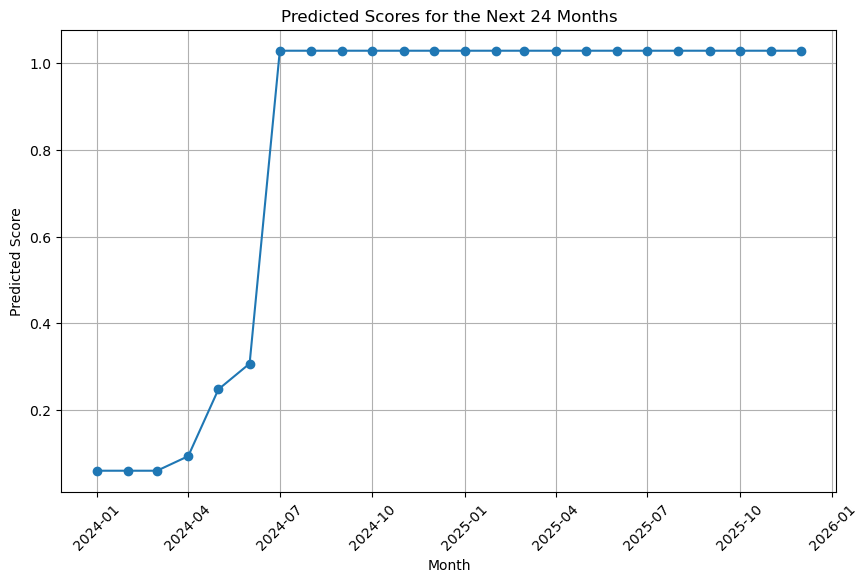

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Vorausgesetzt, die LabelEncoder und das trainierte Modell sind bereits initialisiert
# Beispielhafte Kodierungswerte (diese müssen basierend auf deinen Daten ersetzt werden)
company_encoded = 2  # Angenommener kodierter Wert für "VESTAS WIND SYSTEMS"
supersector_encoded = 1  # Angenommener kodierter Wert für "Oil & Gas"
practice_encoded = 50  # Angenommener kodierter Wert für "BMI-CCF-Capability Focus"

# Startmonat für die Vorhersagen
start_month = pd.Timestamp('2024-01')

# Berechnung von 'month_num' für den Startmonat relativ zum Dataset
min_month = df['month'].min()
start_month_num = ((start_month.year - min_month.year) * 12 + start_month.month - min_month.month)

# Anzahl der Vorhersagen
num_predictions = 24

# Initiale Scores für Lag-Features, angepasst für 6 Lags
initial_lag_scores = [0.0 for _ in range(6)]  # Starte mit Nullen oder den letzten bekannten Werten
predictions = []

for i in range(num_predictions):
    # Update 'month_num' für den aktuellen Vorhersagemonat
    month_num = start_month_num + i

    # Bereite den Feature-Vektor für die Vorhersage vor
    features = [company_encoded, supersector_encoded, practice_encoded, month_num] + initial_lag_scores
    X_predict = np.array([features])

    # Mache die Vorhersage des Scores
    predicted_score = gbm_model.predict(X_predict)[0]

    # Sicherstellen, dass der Score nur steigt oder gleich bleibt
    if i > 0 and predicted_score < predictions[-1]:
        predicted_score = predictions[-1]

    # Speichere die Vorhersage
    predictions.append(predicted_score)

    # Aktualisiere die Lag-Features für die nächste Vorhersage
    initial_lag_scores = initial_lag_scores[1:] + [predicted_score]

# Erstelle einen DataFrame für die Visualisierung
prediction_months = [start_month + pd.DateOffset(months=i) for i in range(num_predictions)]
predictions_df = pd.DataFrame({
    'month': prediction_months,
    'predicted_score': predictions
})

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o')
plt.title('Predicted Scores for the Next 24 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


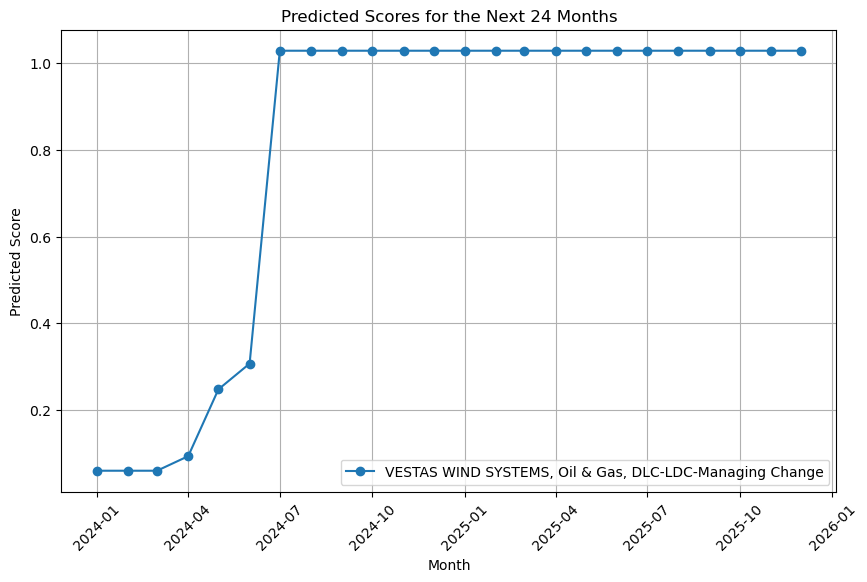

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

# Angenommen, dies sind die tatsächlichen Namen
actual_company_name = "VESTAS WIND SYSTEMS"
actual_supersector_name = "Oil & Gas"
actual_practice_name = "DLC-LDC-Managing Change"

# Plot der vorhergesagten Scores mit tatsächlichen Namen
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o', label=f"{actual_company_name}, {actual_supersector_name}, {actual_practice_name}")
plt.title('Predicted Scores for the Next 24 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()




In [47]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Schritt 1: Laden der Daten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Sicherstellen, dass der Score nur steigen kann
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Schritt 2: Vorbereitung der Lag-Features
for lag in range(1, 7):
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)

# Vorwärtsfüllen der NaN-Werte in den Lag-Features
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)

# Schritt 3: Konvertierung der kategorialen Variablen in den Typ 'category'
df['Company Name Full'] = df['Company Name Full'].astype('category')
df['Supersector'] = df['Supersector'].astype('category')
df['practice'] = df['practice'].astype('category')

# Umwandlung des Monats in eine numerische Spalte
df['month_num'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month

# Schritt 4: Auswahl der Features und des Zielwerts
X = df[['Company Name Full', 'Supersector', 'practice', 'month_num'] + [f'score_lag{lag}' for lag in range(1, 7)]]
y = df['score']

# Schritt 5: Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Schritt 6: Training des LightGBM-Modells
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

gbm_model = lgb.train(params,
                      train_data,
                      valid_sets=[valid_data],
                      num_boost_round=1000)

# Schritt 7: Evaluierung des Modells
y_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_16791/2310344994.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Mean Squared Error: 0.7120653695194931


In [48]:
# Angenommene Namen für Unternehmen, Supersektor und Praktiken
actual_company_name = "VESTAS WIND SYSTEMS"
actual_supersector_name = "Oil & Gas"
actual_practice_name = "DLC-LDC-Managing Change"

# Datumsbereich für die Vorhersagen erstellen
prediction_dates = pd.date_range(start="2024-01", periods=24, freq='M')

# Vorhersagen generieren
predictions = []
for date in prediction_dates:
    X_pred = pd.DataFrame({
        'Company Name Full': [actual_company_name],
        'Supersector': [actual_supersector_name],
        'practice': [actual_practice_name],
        'month': [date]
    })
    # Die kategorialen Spalten auf den Typ 'category' setzen
    for col in ['Company Name Full', 'Supersector', 'practice']:
        X_pred[col] = X_pred[col].astype('category')
    pred_score = model.predict(X_pred)
    predictions.append(pred_score[0])

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(prediction_dates, predictions, marker='o', label=f"{actual_company_name}, {actual_supersector_name}, {actual_practice_name}")
plt.title('Predicted Scores for the Next 24 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- month
Feature names seen at fit time, yet now missing:
- month_num
- score_lag1
- score_lag2
- score_lag3
- score_lag4
- ...


In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import lightgbm as lgb

# Angenommene Namen für Unternehmen, Supersektor und Praktiken
actual_company_name = "VESTAS WIND SYSTEMS"
actual_supersector_name = "Oil & Gas"
actual_practice_name = "BMI-OE-Outsourcing Implementation"

# Datumsbereich für die Vorhersagen erstellen
prediction_dates = pd.date_range(start="2024-01", periods=24, freq='M')
predictions = []

# Vorbereitung des DataFrame für die Vorhersage
for date in prediction_dates:
    month_num = (date.year - df['month'].dt.year.min()) * 12 + date.month
    X_pred = pd.DataFrame({
        'Company Name Full': [actual_company_name],
        'Supersector': [actual_supersector_name],
        'practice': [actual_practice_name],
        'month_num': [month_num],
        # Hier fügen wir die initialen Werte für Lag-Features ein. Diese sollten entsprechend deinen Daten angepasst werden.
        'score_lag1': [1], 'score_lag2': [1], 'score_lag3': [2], 'score_lag4': [2], 'score_lag5': [3], 'score_lag6': [3]
    })

    # Achte darauf, die kategorialen Spalten entsprechend zu konvertieren, falls erforderlich
    for col in ['Company Name Full', 'Supersector', 'practice']:
        X_pred[col] = X_pred[col].astype('category')

    # Vorhersage
    pred_score = gbm_model.predict(X_pred)
    predictions.append(pred_score[0])

# Erstelle einen DataFrame für die Visualisierung
predictions_df = pd.DataFrame({
    'month': prediction_dates,
    'predicted_score': predictions
})

# Plot der vorhergesagten Scores
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o', label=f"{actual_company_name}, {actual_supersector_name}, {actual_practice_name}")
plt.title('Predicted Scores for the Next 24 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


ValueError: train and valid dataset categorical_feature do not match.

In [38]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Schritt 1: Daten laden und vorbereiten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Erstellung von Lag-Features und rollierenden Durchschnittsfeatures
for lag in range(1, 7):
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)
    # Rollender Durchschnitt über die letzten 3 Monate
    df[f'rolling_avg{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].transform(lambda x: x.shift(lag).rolling(window=3, min_periods=1).mean())

# Füllen von NaN-Werten
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)

# Umwandlung des Monats in eine numerische Darstellung
df['month_num'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month

# Vorbereitung der Features und Zielvariablen
feature_columns = ['Company Name Full', 'Supersector', 'practice', 'month_num'] + [f'score_lag{lag}' for lag in range(1, 7)] + [f'rolling_avg{lag}' for lag in range(1, 7)]
X = df[feature_columns]
y = df['score']

# Kategorische Features als 'category' behandeln
categorical_features = ['Company Name Full', 'Supersector', 'practice']
X[categorical_features] = X[categorical_features].astype('category')

# Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training des LightGBM-Modells
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features, reference=train_data)

gbm_model = lgb.train(params,
                      train_data,
                      valid_sets=[valid_data],
                      num_boost_round=1000)

# Evaluierung des Modells
y_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


KeyboardInterrupt: 

In [39]:
#richtiges Modell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Schritt 1: Daten laden und vorbereiten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Stelle sicher, dass der Score nur steigen oder gleich bleiben darf
df['score'] = df.groupby(['Company Name Full', 'Supersector', 'practice'])['score'].cummax()

# Anwendung von LabelEncoder auf kategorische Features
categorical_features = ['Company Name Full', 'Supersector', 'practice']
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])
    label_encoders[feature] = le

# Erstellung von Lag-Features und rollierenden Durchschnittsfeatures
for lag in range(1, 7):
    df[f'score_lag{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(lag)
    df[f'rolling_avg{lag}'] = df.groupby(['Company Name Full', 'practice'])['score'].transform(lambda x: x.shift(lag).rolling(window=3, min_periods=1).mean())

# Füllen von NaN-Werten
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)

# Umwandlung des Monats in eine numerische Darstellung
df['month_num'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month

# Vorbereitung der Features und Zielvariablen
feature_columns = ['Company Name Full', 'Supersector', 'practice', 'month_num'] + [f'score_lag{lag}' for lag in range(1, 7)] + [f'rolling_avg{lag}' for lag in range(1, 7)]
X = df[feature_columns]
y = df['score']

# Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training des LightGBM-Modells
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features, reference=train_data)

gbm_model = lgb.train(params, train_data, valid_sets=[valid_data], num_boost_round=1000)

# Evaluierung des Modells
y_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Generieren von Vorhersagen für zukünftige Monate (optionaler Schritt, abhängig von deiner spezifischen Anforderung)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_22274/3364608479.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Mean Squared Error: 0.7118126120157711


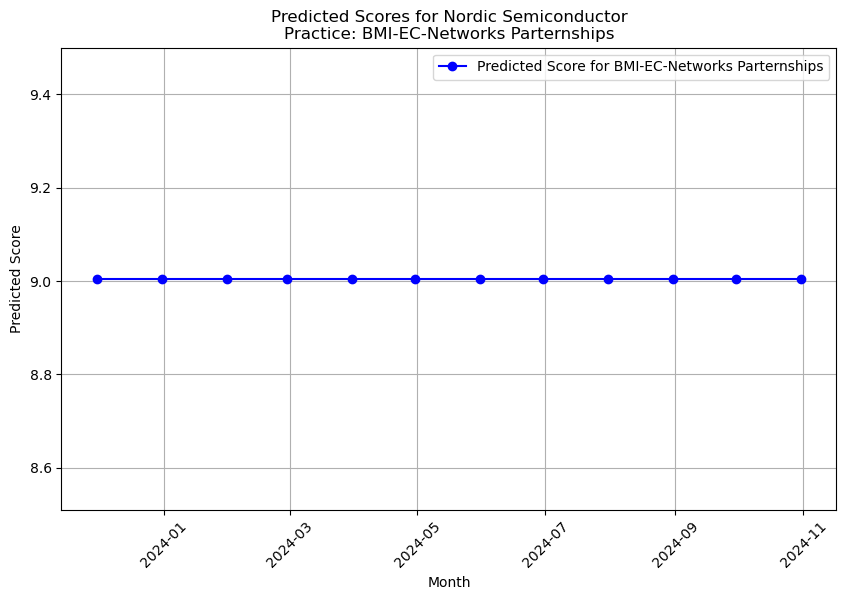

In [51]:
# Definiere die spezifischen Details
company_name = "Nordic Semiconductor"
practice_name = "BMI-EC-Networks Parternships"

# Kodiere die kategorischen Variablen mit den zuvor gespeicherten LabelEncoders
company_encoded = label_encoders['Company Name Full'].transform([company_name])[0]
practice_encoded = label_encoders['practice'].transform([practice_name])[0]

# Bereite die Daten für die Vorhersage vor
start_month = pd.Timestamp('2023-11')  # Angenommen, die Vorhersage beginnt im Februar 2024
prediction_months = pd.date_range(start=start_month, periods=12, freq='M')  # Vorhersage für 12 Monate
month_nums = (prediction_months.year - df['month'].dt.year.min()) * 12 + prediction_months.month

# Initialisiere ein DataFrame für die Vorhersagen
X_pred = pd.DataFrame({
    'Company Name Full': [company_encoded] * len(prediction_months),
    'Supersector': [label_encoders['Supersector'].transform([actual_supersector_name])[0]] * len(prediction_months),
    'practice': [practice_encoded] * len(prediction_months),
    'month_num': month_nums
})

# Füge Lag-Features und rollierende Durchschnitte basierend auf den letzten bekannten Werten hinzu
for lag in range(1, 7):
    X_pred[f'score_lag{lag}'] = df[df['Company Name Full'] == company_encoded][f'score_lag{lag}'].iloc[-1]
    X_pred[f'rolling_avg{lag}'] = df[df['Company Name Full'] == company_encoded][f'rolling_avg{lag}'].iloc[-1]

# Mache die Vorhersagen
predictions = gbm_model.predict(X_pred)

# Stelle sicher, dass die Scores nur gleich bleiben oder steigen
for i in range(1, len(predictions)):
    predictions[i] = max(predictions[i], predictions[i-1])

# Plot der Vorhersageergebnisse
plt.figure(figsize=(10, 6))
plt.plot(prediction_months, predictions, marker='o', linestyle='-', color='blue', label=f'Predicted Score for {practice_name}')
plt.title(f'Predicted Scores for {company_name}\nPractice: {practice_name}')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


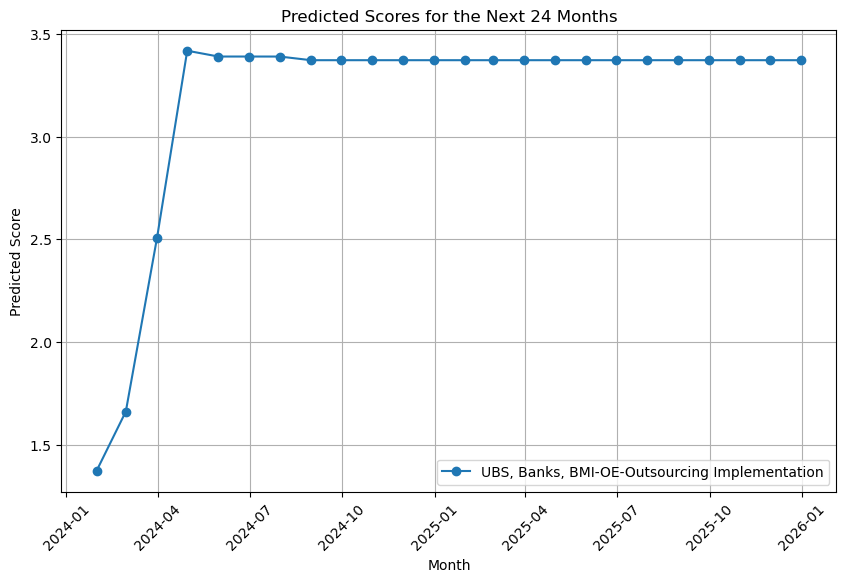

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

# Laden des trainierten LightGBM-Modells
# gbm_model = ...

# Daten laden (angepasst an deinen tatsächlichen Dateipfad und Datenstruktur)
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Spezifische Auswahl
actual_company_name = "UBS"
actual_supersector_name = "Banks"
actual_practice_name = "BMI-OE-Outsourcing Implementation"

# Extrahiere die letzten 6 monatlichen Scores für das Zielunternehmen
df_filtered = df[(df['Company Name Full'] == actual_company_name) & 
                 (df['Supersector'] == actual_supersector_name) & 
                 (df['practice'] == actual_practice_name)]

# Stelle sicher, dass df_filtered nach 'month' sortiert ist, um die letzten 6 Werte korrekt zu extrahieren
historical_scores = df_filtered['score'].tail(6).tolist()

# Überprüfen, ob weniger als 6 historische Werte vorhanden sind und ggf. mit 0 auffüllen
if len(historical_scores) < 6:
    historical_scores = [0]*(6-len(historical_scores)) + historical_scores

# Vorhersageperiode definieren
start_month = pd.Timestamp('2024-01')
prediction_months = pd.date_range(start=start_month, periods=24, freq='M')

predictions = []
lag_scores = historical_scores.copy()

for month in prediction_months:
    month_num = (month.year - df['month'].dt.year.min()) * 12 + month.month - df['month'].dt.month.min()
    
    # Bereite den DataFrame für die Vorhersage vor
    X_pred = pd.DataFrame({
        'Company Name Full': [actual_company_name],
        'Supersector': [actual_supersector_name],
        'practice': [actual_practice_name],
        'month_num': [month_num],
        **{f'score_lag{i+1}': [lag_scores[-(i+1)]] for i in range(6)}
    })

    for col in ['Company Name Full', 'Supersector', 'practice']:
        X_pred[col] = X_pred[col].astype('category')
    
    # Mache die Vorhersage
    pred_score = gbm_model.predict(X_pred)[0]
    predictions.append(pred_score)
    
    # Aktualisiere die Lag-Scores mit dem zuletzt vorhergesagten Score für die nächste Runde
    lag_scores.append(pred_score)
    lag_scores = lag_scores[1:]  # Halte die Liste auf 6 Elemente beschränkt

# Plot der Vorhersageergebnisse
predictions_df = pd.DataFrame({
    'month': prediction_months,
    'predicted_score': predictions
})

plt.figure(figsize=(10, 6))
plt.plot(predictions_df['month'], predictions_df['predicted_score'], marker='o', label=f"{actual_company_name}, {actual_supersector_name}, {actual_practice_name}")
plt.title('Predicted Scores for the Next 24 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


In [52]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
import lightgbm as lgb

# Annahme: gbm_model ist dein trainiertes LightGBM-Modell
# gbm_model = ...

# Daten laden
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Bestimme den maximalen historischen Score pro Praxis und Unternehmen bis zum letzten historischen Datum
max_historical_scores = df.groupby(['Company Name Full', 'practice'])['score'].max()

# Wähle nur das Unternehmen "VESTAS WIND SYSTEMS"
df_vestas = df[df['Company Name Full'] == "VESTAS WIND SYSTEMS"]

# Definiere die Vorhersageperiode
start_month = pd.Timestamp('2024-01')
prediction_months = pd.date_range(start=start_month, periods=6, freq='M')

# Extrahiere historische Scores für jede Praxis
new_rows = []
for practice, group in df_vestas.groupby('practice'):
    
    # Extrahiere die letzten 6 monatlichen Scores
    historical_scores = group['score'].tail(6).tolist()
    if len(historical_scores) < 6:
        historical_scores = [0] * (6 - len(historical_scores)) + historical_scores

    lag_scores = historical_scores.copy()

    for month in prediction_months:
        month_num = (month.year - df['month'].dt.year.min()) * 12 + month.month - df['month'].dt.month.min()
        
        # Vorbereiten des Feature-Vektors für die Vorhersage
        X_pred = pd.DataFrame({
            'Company Name Full': [df_vestas['Company Name Full'].iloc[0]],  # "VESTAS WIND SYSTEMS" kodiert
            'Supersector': [df_vestas['Supersector'].iloc[0]],  # Supersector kodiert
            'practice': [practice],  # Praxis kodiert
            'month_num': [month_num],
            **{f'score_lag{i+1}': [lag_scores[-(i+1)]] for i in range(6)}
        })

        for col in ['Company Name Full', 'Supersector', 'practice']:
            X_pred[col] = X_pred[col].astype('category')
        
        predicted_score = gbm_model.predict(X_pred)[0]
        # Stelle sicher, dass der vorhergesagte Score nicht unter dem maximalen historischen Score liegt
        adjusted_score = max(predicted_score, max_historical_scores.get((group['Company Name Full'].iloc[0], practice), 0))
        
        # Aktualisiere Lag-Scores
        lag_scores.append(adjusted_score)
        lag_scores.pop(0)  # Halte die Liste auf 6 Elemente beschränkt
        
        new_rows.append({
            'Company Name Full': group['Company Name Full'].iloc[0],
            'Supersector': group['Supersector'].iloc[0],
            'practice': practice,
            'month': month.strftime('%Y-%m-%d'),
            'score': adjusted_score
        })

# Erstelle einen DataFrame aus den neuen Zeilen
df_new_rows = pd.DataFrame(new_rows)

# Füge die neuen Zeilen zum ursprünglichen DataFrame hinzu
df_extended = pd.concat([df, df_new_rows], ignore_index=True)

# Sortiere den erweiterten DataFrame
df_extended.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Anzeigen des erweiterten DataFrame
print(df_extended.head())

# Optional: Speichern des erweiterten DataFrame
# df_extended.to_csv('/path/to/your/extended_data_with_predictions.csv', index=False)


ValueError: train and valid dataset categorical_feature do not match.

In [2]:
#richtiger Code für DF predicten

import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
import lightgbm as lgb

# Annahme: gbm_model ist dein trainiertes LightGBM-Modell
# gbm_model = ...

# Daten laden
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Bestimme den maximalen historischen Score pro Praxis und Unternehmen bis zum letzten historischen Datum
max_historical_scores = df.groupby(['Company Name Full', 'practice'])['score'].max()

# Wähle nur das Unternehmen "VESTAS WIND SYSTEMS"
df_vestas = df[df['Supersector'] == "Retail"]

# Definiere die Vorhersageperiode
start_month = pd.Timestamp('2024-01')
prediction_months = pd.date_range(start=start_month, periods=6, freq='M')

# Extrahiere historische Scores für jede Praxis
new_rows = []
for (company, practice), group in df_vestas.groupby(['Company Name Full', 'practice']):
    
    # Extrahiere die letzten 6 monatlichen Scores
    historical_scores = group['score'].tail(6).tolist()
    if len(historical_scores) < 6:
        historical_scores = [0] * (6 - len(historical_scores)) + historical_scores

    lag_scores = historical_scores.copy()
    # Hole den maximalen historischen Score für die Kombination aus Unternehmen und Praxis
    max_historical_score_key = (company, practice)
    max_historical_score = max_historical_scores[max_historical_score_key]

    for month in prediction_months:
        month_num = (month.year - df['month'].dt.year.min()) * 12 + month.month - df['month'].dt.month.min()
        
        X_pred = pd.DataFrame({
            'Company Name Full': [company],
            'Supersector': [group['Supersector'].iloc[0]],  # Verwende den Supersektor der Praxis
            'practice': [practice],
            'month_num': [month_num],
            **{f'score_lag{i+1}': [lag_scores[-(i+1)]] for i in range(6)}
        })

        for col in ['Company Name Full', 'Supersector', 'practice']:
            X_pred[col] = X_pred[col].astype('category')
        
        predicted_score = gbm_model.predict(X_pred)[0]
        # Stelle sicher, dass der vorhergesagte Score nicht unter dem maximalen historischen Score liegt
        adjusted_score = max(predicted_score, max_historical_score)
        
        lag_scores.append(adjusted_score)
        lag_scores = lag_scores[1:]  # Halte die Liste auf 6 Elemente beschränkt
        
        new_rows.append({
            'Company Name Full': company,
            'Supersector': group['Supersector'].iloc[0],
            'practice': practice,
            'month': month,
            'score': adjusted_score
        })

# Erstelle einen DataFrame aus den neuen Zeilen
df_new_rows = pd.DataFrame(new_rows)

# Füge die neuen Zeilen zum ursprünglichen DataFrame hinzu
df_extended = pd.concat([df, df_new_rows], ignore_index=True)

# Sortiere den erweiterten DataFrame
df_extended.sort_values(by=['Company Name Full', 'Supersector', 'practice', 'month'], inplace=True)

# Anzeigen oder Speichern des erweiterten DataFrame
print(df_extended.head())
# df_extended.to_csv('/path/to/your/extended_data.csv', index=False)


   Unnamed: 0                  practice Company Name Full      month  \
0         0.0  BMI-CCF-Capability Focus            3I GRP 2021-01-01   
1         1.0  BMI-CCF-Capability Focus            3I GRP 2021-02-01   
2         2.0  BMI-CCF-Capability Focus            3I GRP 2021-03-01   
3         3.0  BMI-CCF-Capability Focus            3I GRP 2021-04-01   
4         4.0  BMI-CCF-Capability Focus            3I GRP 2021-05-01   

          Supersector capability pillar  cumulative_volume_per_month  p10  \
0  Financial Services        CCF    BMI                          0.0  0.0   
1  Financial Services        CCF    BMI                          0.0  0.0   
2  Financial Services        CCF    BMI                          0.0  0.0   
3  Financial Services        CCF    BMI                          0.0  0.0   
4  Financial Services        CCF    BMI                          0.0  0.0   

   p20  p30  p40  p50  p60  p70  p80       p90       p100  score  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0 

In [3]:
df_retail = df_extended[df_extended['Supersector'] == "Retail"]

# Anzeigen der Zeilen für "VESTAS WIND SYSTEMS"
print(df_vestas)


         Unnamed: 0                          practice Company Name Full  \
629             629          BMI-CCF-Capability Focus             AHOLD   
630             630          BMI-CCF-Capability Focus             AHOLD   
631             631          BMI-CCF-Capability Focus             AHOLD   
632             632          BMI-CCF-Capability Focus             AHOLD   
633             633          BMI-CCF-Capability Focus             AHOLD   
...             ...                               ...               ...   
3255181     3255181  TI-SDH-Data Storage Optimization           ZALANDO   
3255182     3255182  TI-SDH-Data Storage Optimization           ZALANDO   
3255183     3255183  TI-SDH-Data Storage Optimization           ZALANDO   
3255184     3255184  TI-SDH-Data Storage Optimization           ZALANDO   
3255185     3255185  TI-SDH-Data Storage Optimization           ZALANDO   

             month Supersector capability pillar  cumulative_volume_per_month  \
629     2021-01-01

In [16]:
df_retail.head(83)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
104414,629.0,BMI-CCF-Capability Focus,AHOLD,2021-01-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104415,630.0,BMI-CCF-Capability Focus,AHOLD,2021-02-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104416,631.0,BMI-CCF-Capability Focus,AHOLD,2021-03-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104417,632.0,BMI-CCF-Capability Focus,AHOLD,2021-04-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104418,633.0,BMI-CCF-Capability Focus,AHOLD,2021-05-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.239710,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104486,20274.0,BMI-CCF-Core Development,AHOLD,2023-12-01,Retail,CCF,BMI,0.0,0.0,0.0,0.000000,0.000000,0.000000,6.256327,9.152562,12.363732,22.332399,48.261190,0.000000
104487,20275.0,BMI-CCF-Core Development,AHOLD,2024-01-01,Retail,CCF,BMI,0.0,0.0,0.0,1.049423,5.771094,7.170267,9.123764,11.200160,12.757267,17.058147,33.967527,0.000000
3255266,NaN,BMI-CCF-Core Development,AHOLD,2024-01-31,Retail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000
3255267,NaN,BMI-CCF-Core Development,AHOLD,2024-02-29,Retail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000


In [ ]:
df_retail

In [25]:
# Finde die Einträge für den Monat 2024-01 für jede Kombination aus Praxis und Unternehmen
base_values_df = df_retail[(df_retail['month'] == "2024-01-01")]
comparison_date = pd.Timestamp("2024-01-01")

# Gehe durch alle Zeilen im erweiterten DataFrame
for index, row in df_retail.iterrows():
    if row['month'] > comparison_date:
        # Identifiziere die Zeile im Basis-DataFrame, die mit der aktuellen Praxis und Unternehmen übereinstimmt
        base_row = base_values_df[(base_values_df['Company Name Full'] == row['Company Name Full']) &
                                  (base_values_df['practice'] == row['practice'])]

        if not base_row.empty:
            # Aktualisiere die 'capability' und 'pillar' Werte für die Vorhersagezeile mit den Werten von 2024-01
            df_retail.at[index, 'capability'] = base_row['capability'].values[0]
            df_retail.at[index, 'pillar'] = base_row['pillar'].values[0]

# Überprüfe das Ergebnis
print(df_retail.tail())


         Unnamed: 0                          practice Company Name Full  \
3274179         NaN  TI-SDH-Data Storage Optimization           ZALANDO   
3274180         NaN  TI-SDH-Data Storage Optimization           ZALANDO   
3274181         NaN  TI-SDH-Data Storage Optimization           ZALANDO   
3274182         NaN  TI-SDH-Data Storage Optimization           ZALANDO   
3274183         NaN  TI-SDH-Data Storage Optimization           ZALANDO   

             month Supersector capability pillar  cumulative_volume_per_month  \
3274179 2024-02-29      Retail        SDH     TI                          NaN   
3274180 2024-03-31      Retail        SDH     TI                          NaN   
3274181 2024-04-30      Retail        SDH     TI                          NaN   
3274182 2024-05-31      Retail        SDH     TI                          NaN   
3274183 2024-06-30      Retail        SDH     TI                          NaN   

         p10  p20  p30  p40  p50  p60  p70  p80  p90  p100  sc

In [28]:
df_retail.head(350)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
104414,629.0,BMI-CCF-Capability Focus,AHOLD,2021-01-01,Retail,CCF,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
104415,630.0,BMI-CCF-Capability Focus,AHOLD,2021-02-01,Retail,CCF,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
104416,631.0,BMI-CCF-Capability Focus,AHOLD,2021-03-01,Retail,CCF,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
104417,632.0,BMI-CCF-Capability Focus,AHOLD,2021-04-01,Retail,CCF,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
104418,633.0,BMI-CCF-Capability Focus,AHOLD,2021-05-01,Retail,CCF,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4.239710,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104711,157510.0,BMI-EC-Integration Strategies,AHOLD,2021-02-01,Retail,EC,BMI,5.114022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.022804,44.277028,9.0
104712,157511.0,BMI-EC-Integration Strategies,AHOLD,2021-03-01,Retail,EC,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
104713,157512.0,BMI-EC-Integration Strategies,AHOLD,2021-04-01,Retail,EC,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,100.999625,0.0
104714,157513.0,BMI-EC-Integration Strategies,AHOLD,2021-05-01,Retail,EC,BMI,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,63.595643,0.0


In [29]:
df_retail.to_csv("Extended_Retail_Data.csv")

In [ ]:
# Konvertiere '2024-01' String zu einem pd.Timestamp für den korrekten Vergleich
comparison_date = pd.Timestamp('2024-01-31')

# Basiswerte aus dem Monat Januar 2024 für jede Kombination aus Praxis und Unternehmen extrahieren
base_values_df = df_extended[(df_extended['month'] <= comparison_date) & 
                             (df_extended['Company Name Full'] == "VESTAS WIND SYSTEMS")]

# Erstelle einen leeren DataFrame für die neuen Zeilen
new_rows = []

# Iteriere durch die Vorhersagezeilen
for month in prediction_months:
    for _, row in base_values_df.iterrows():
        # Kopiere 'capability' und 'pillar' aus den Basiswerten
        capability = row['capability']
        pillar = row['pillar']
        
        # Füge die neue Vorhersagezeile hinzu
        new_rows.append({
            'Company Name Full': "VESTAS WIND SYSTEMS",
            'Supersector': row['Supersector'],  # Angenommen, dieser Wert ändert sich nicht und kann direkt kopiert werden
            'practice': row['practice'],
            'month': month,
            'score': np.nan,  # Setze den Score vorläufig auf NaN
            'capability': capability,
            'pillar': pillar,
            # Füge weitere notwendige Spalten hier hinzu
        })

# Erstelle einen DataFrame aus den neuen Zeilen
df_new_predictions = pd.DataFrame(new_rows)

# Jetzt, wo du die neuen Vorhersagezeilen hast, kannst du sie mit den vorhandenen historischen Daten zusammenführen
df_final = pd.concat([df_extended, df_new_predictions], ignore_index=True).sort_values(by=['Company Name Full', 'practice', 'month'])

# Vergewissere dich, dass der 'month' korrekt als Datumsformat gesetzt ist
df_final['month'] = pd.to_datetime(df_final['month'])

# Führe nun die Logik zum Anpassen der Scores basierend auf historischen Maxima durch (bereits in vorherigen Schritten erklärt)

# Zeige den finalen DataFrame an oder speichere ihn
print(df_final.head())

# Optional: Speichere den finalen DataFrame
# df_final.to_csv('/path/to/your/final_data.csv', index=False)


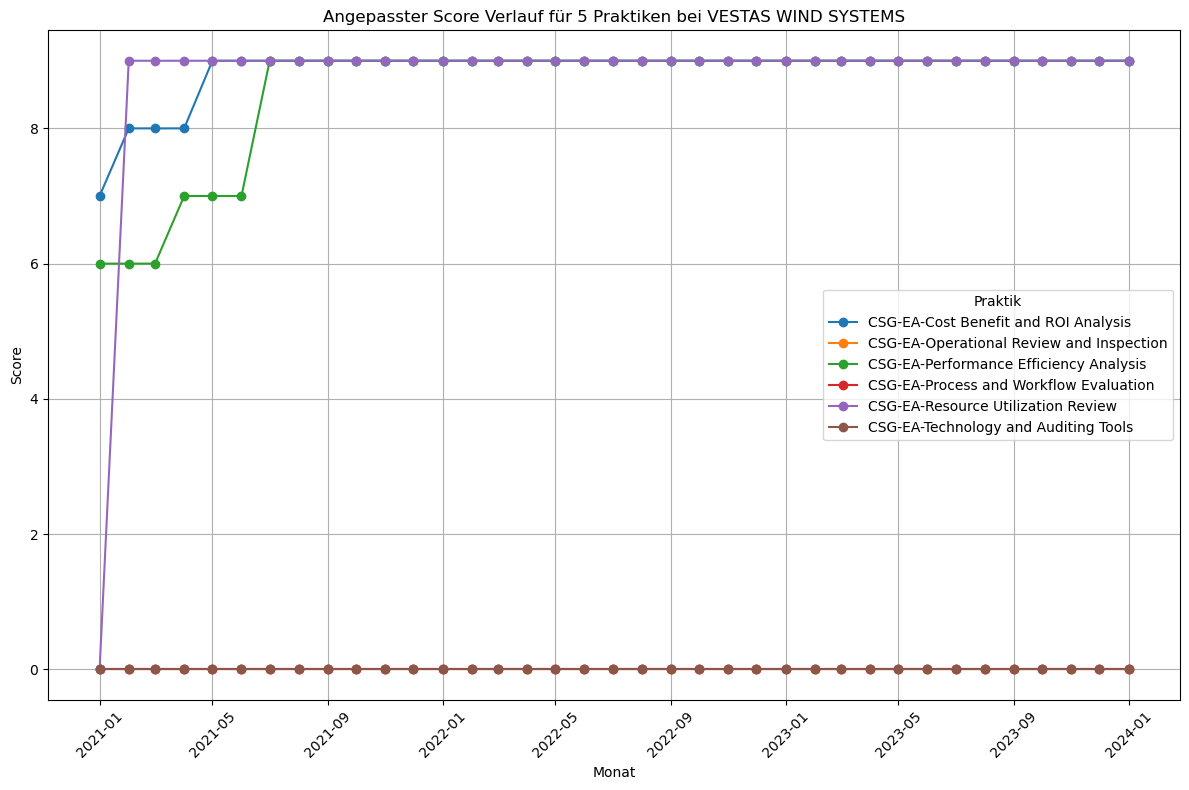

In [123]:
import matplotlib.pyplot as plt

# Angenommen, df_vestas ist bereits definiert und enthält Daten für "VESTAS WIND SYSTEMS"
# Wähle bis zu 5 Praktiken aus
unique_practices = df_vestas['practice'].unique()[50:56]

# Erstelle den Plot
plt.figure(figsize=(12, 8))

for practice in unique_practices:
    # Filtere die Daten für die aktuelle Praxis
    practice_data = df_vestas[df_vestas['practice'] == practice]
    
    # Sortiere die Daten nach Monat, um sicherzustellen, dass cummax korrekt angewendet wird
    practice_data = practice_data.sort_values(by='month')
    
    # Wende cummax auf den Score an, um sicherzustellen, dass er niemals abnimmt
    practice_data['adjusted_score'] = practice_data['score'].cummax()
    
    # Plotte den angepassten Score-Verlauf für die Praxis
    plt.plot(practice_data['month'], practice_data['adjusted_score'], marker='o', label=practice)

plt.title('Angepasster Score Verlauf für 5 Praktiken bei VESTAS WIND SYSTEMS')
plt.xlabel('Monat')
plt.ylabel('Score')
plt.legend(title='Praktik')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Zeige den Plot an
plt.show()
